# Stress-episode workbench

Step 3 of the alpha roadmap. Step 1 found that the only edge clearing costs came
from a handful of crash and cascade days. This notebook studies those days
directly as discrete episodes rather than as a continuous factor.

**Detection** runs on a 1-second grid built from `timestamp_direction_v1`
events. At each second, $z$ is the largest move over the trailing 30, 60 and 300
seconds, in units of trailing-24h one-minute volatility scaled by
$\sqrt{W/60}$. The episode threshold is calibrated on 2021–2022 to a target
episode rate and frozen for January 2023 to May 2026. Qualifying seconds less
than 30 minutes apart form one episode, and the trigger is its first qualifying
second.

**Returns are reported as reversion**: positive means price moved back against
the triggering move.

Open interest is used in two separate ways:

- `oi_change_1h_realtime_pct`: one-hour change up to the latest 5-minute
  snapshot at least five minutes before the trigger. It is known at decision time.
- `oi_change_episode_label_pct`: change from before the move to 15 minutes
  after the trigger. It is an **ex-post label** for understanding episode type,
  not a tradable feature.

June–August 2026 are excluded; late-May paths are truncated rather than
extended into holdout data.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
INK, MUTED = '#2b2b2b', '#8a8a85'
RNG = np.random.default_rng(20_260_929)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 115,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#e6e6e3',
    'lines.linewidth': 2,
})
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_float_precision(2)


def day_bootstrap(values, days, reps=2000):
    # Mean and 95% interval resampling whole UTC days of episodes.
    values = np.asarray(values, dtype=float)
    days = np.asarray(days)
    keep = np.isfinite(values)
    values, days = values[keep], days[keep]
    if len(values) < 3:
        return np.nan, np.nan, np.nan
    unique, inverse = np.unique(days, return_inverse=True)
    sums = np.bincount(inverse, weights=values)
    counts = np.bincount(inverse)
    draws = RNG.integers(0, len(unique), size=(reps, len(unique)))
    means = sums[draws].sum(axis=1) / counts[draws].sum(axis=1)
    return values.mean(), *np.quantile(means, [0.025, 0.975])

## Manual controls

In [2]:
EXPERIMENT = 'stress_episodes_v2'   # v1: 30s-5m spike triggers; v2: 15m/60m moves
TARGET_PER_YEAR = 100      # 50, 100 or 200 calibrated episodes per year
PERIOD = 'test'            # 'test' (2023-01..2026-05) or 'calibration' (2021-22)
HOLDING_SECONDS = 900      # 300, 900, 1800 or 3600
RULE = 'trigger'           # trigger, delay_Ns, exhaustion_30s or exhaustion_60s

RESULTS = REPO / 'alpha-search' / 'reports' / EXPERIMENT
config = json.loads(
    (REPO / 'alpha-search' / 'configs' / f'{EXPERIMENT}.json').read_text()
)
manifest = json.loads((RESULTS / 'run_manifest.json').read_text())
episodes_all = pl.read_parquet(RESULTS / 'episodes.parquet').with_columns(
    pl.from_epoch('trigger_second').dt.date().alias('day'),
    pl.from_epoch('trigger_second').dt.year().alias('year'),
)
paths_all = pl.read_parquet(RESULTS / 'paths.parquet')
trades_all = pl.read_parquet(RESULTS / 'trades.parquet')
TAKER = 2 * config['costs_bps_per_side']['taker']

assert TARGET_PER_YEAR in config['target_episodes_per_year']
assert PERIOD in {'test', 'calibration'}
assert HOLDING_SECONDS in config['holding_horizons_seconds']

episodes = episodes_all.filter(
    (pl.col('target_per_year') == TARGET_PER_YEAR) & (pl.col('period') == PERIOD)
)
keys = episodes.select('trigger_second', 'day', 'direction', 'scheduled_release_window',
                       'oi_change_episode_label_pct', 'oi_change_1h_realtime_pct',
                       'aggression_share', 'spread_proxy_bps', 'year')
paths = paths_all.filter(pl.col('target_per_year') == TARGET_PER_YEAR).join(
    keys, on='trigger_second'
)
trades = trades_all.filter(pl.col('target_per_year') == TARGET_PER_YEAR).join(
    keys, on='trigger_second'
).with_columns(
    (pl.col('gross_bps') - TAKER - pl.col('entry_spread_proxy_bps')).alias('net_bps')
)
display(Markdown(
    f"`{EXPERIMENT}`: windows {config['trigger_windows_seconds']} s; "
    f"threshold z = {manifest['thresholds_z'][str(TARGET_PER_YEAR)]:.2f}; "
    f"{episodes.height} {PERIOD} episodes on {episodes['day'].n_unique()} days."
))

`stress_episodes_v2`: windows [900, 3600] s; threshold z = 7.43; 380 test episodes on 321 days.

## 1. Episode catalogue

In [3]:
episodes_all.filter(pl.col('target_per_year') == TARGET_PER_YEAR).group_by('year').agg(
    pl.len().alias('episodes'),
    (pl.col('direction') < 0).sum().alias('down_moves'),
    pl.col('scheduled_release_window').sum().alias('scheduled_release'),
    pl.col('move_bps').median().alias('median_trigger_move_bps'),
    pl.col('oi_change_episode_label_pct').median().alias('median_oi_label_pct'),
).sort('year')

year,episodes,down_moves,scheduled_release,median_trigger_move_bps,median_oi_label_pct
i32,u32,u32,u32,f64,f64
2021,82,49,7,260.84,-2.16
2022,117,68,16,194.28,-1.36
2023,177,88,19,133.31,-1.75
2024,89,56,7,177.58,-0.88
2025,78,40,9,134.57,-0.31
2026,36,19,1,124.12,-0.37


In [4]:
episodes.sort('peak_z', descending=True).select(
    'trigger_time_utc', 'direction', 'trigger_z', 'peak_z', 'move_bps',
    'aggression_share', 'deep_intensity_ratio', 'spread_proxy_bps',
    'scheduled_release_window', 'oi_change_1h_realtime_pct',
    'oi_change_episode_label_pct', 'adverse_excursion_300s_bps'
).head(20)

trigger_time_utc,direction,trigger_z,peak_z,move_bps,aggression_share,deep_intensity_ratio,spread_proxy_bps,scheduled_release_window,oi_change_1h_realtime_pct,oi_change_episode_label_pct,adverse_excursion_300s_bps
str,i64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64
"""2023-10-01T22:15:58+00:00""",1,11.87,34.80,119.00,0.52,3.23,2.86,false,-0.38,-5.98,309.77
"""2023-12-11T02:07:04+00:00""",-1,7.85,30.27,109.90,0.33,4.05,2.07,false,-1.12,-7.01,172.01
"""2025-10-10T20:56:09+00:00""",-1,7.71,26.96,191.79,0.30,3.33,2.73,false,-0.70,-2.54,159.69
"""2025-08-24T19:34:28+00:00""",-1,8.03,24.50,90.36,0.49,2.57,0.75,false,0.12,-1.85,273.85
"""2023-08-17T21:42:44+00:00""",-1,7.51,24.22,194.75,0.41,2.77,1.25,false,-1.48,-7.98,991.86
"""2023-10-16T13:27:19+00:00""",1,7.63,23.77,209.45,0.22,6.85,0.29,false,-1.22,-6.32,757.12
"""2023-03-03T01:21:56+00:00""",-1,7.56,22.60,150.49,0.29,4.18,0.34,false,0.20,-5.72,105.75
"""2023-10-16T05:16:42+00:00""",1,15.17,21.80,169.68,0.75,3.12,24.65,false,0.47,-5.11,160.18
"""2023-10-23T22:41:07+00:00""",1,7.47,20.41,250.89,0.19,3.10,0.70,false,-0.94,-8.64,941.62


## 2. Average reversion path around the trigger

Offsets before zero show the aligned run-up (negative reversion = price moving in
the trigger direction). Shading is a 95% day-block bootstrap interval.

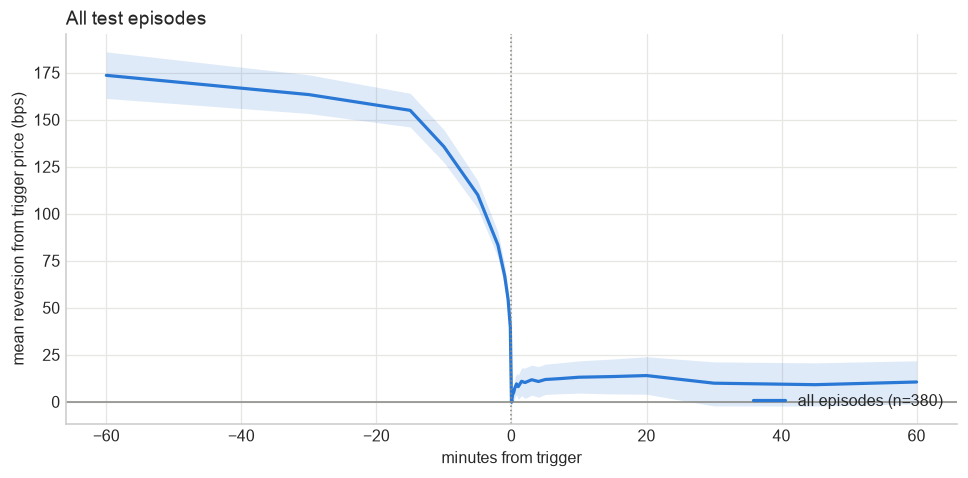

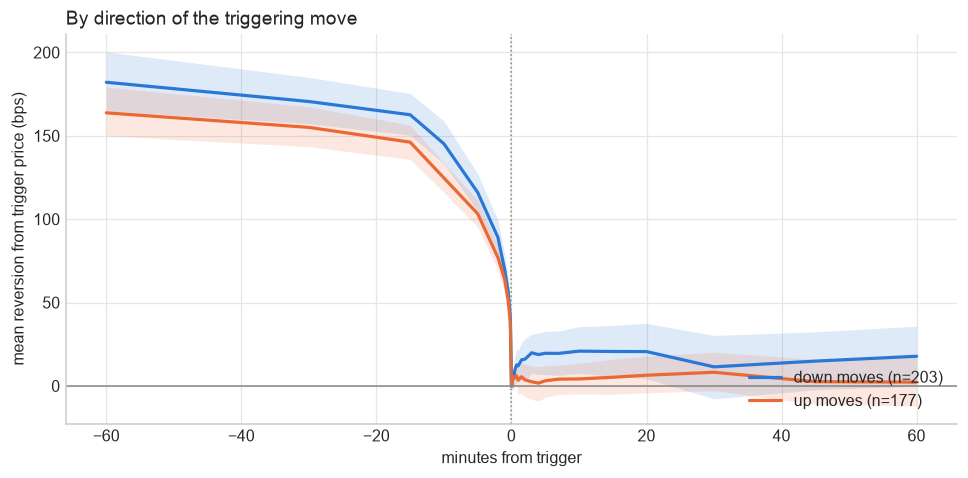

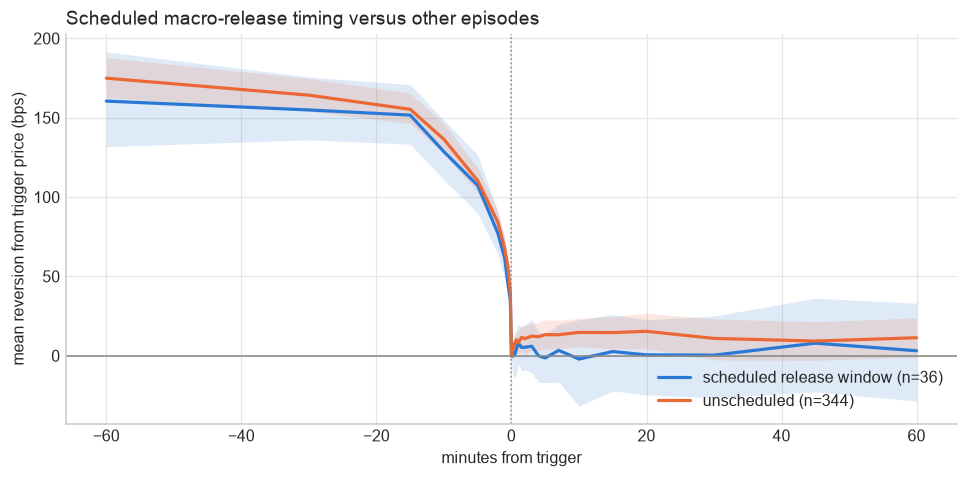

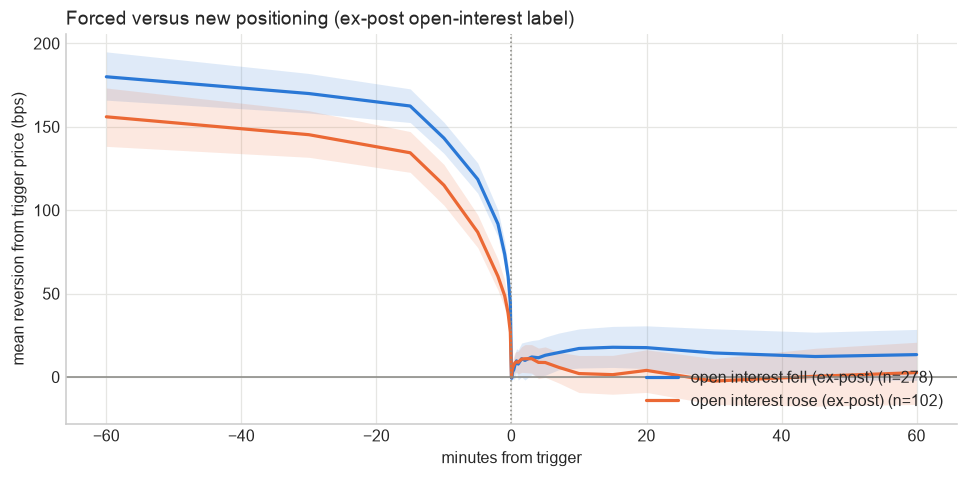

In [5]:
def plot_paths(frame, groups, title):
    fig, ax = plt.subplots(figsize=(10, 4.4))
    for colour, (label, condition) in zip(SERIES, groups):
        subset = frame.filter(condition)
        rows = []
        for offset in sorted(subset['offset_seconds'].unique()):
            chosen = subset.filter(pl.col('offset_seconds') == offset)
            mean, low, high = day_bootstrap(chosen['reversion_bps'], chosen['day'])
            rows.append((offset, mean, low, high))
        rows = np.array(rows, dtype=float)
        count = subset['trigger_second'].n_unique()
        ax.plot(rows[:, 0] / 60, rows[:, 1], color=colour, label=f'{label} (n={count})')
        ax.fill_between(rows[:, 0] / 60, rows[:, 2], rows[:, 3], color=colour, alpha=0.15,
                        linewidth=0)
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.axvline(0, color=MUTED, linewidth=1, linestyle=':')
    ax.set_xlabel('minutes from trigger')
    ax.set_ylabel('mean reversion from trigger price (bps)')
    ax.set_title(title, loc='left')
    ax.legend(frameon=False, loc='lower right')
    plt.show()

plot_paths(paths, [('all episodes', pl.lit(True))], f'All {PERIOD} episodes')
plot_paths(paths, [
    ('down moves', pl.col('direction') < 0),
    ('up moves', pl.col('direction') > 0),
], 'By direction of the triggering move')
plot_paths(paths, [
    ('scheduled release window', pl.col('scheduled_release_window')),
    ('unscheduled', ~pl.col('scheduled_release_window')),
], 'Scheduled macro-release timing versus other episodes')
plot_paths(paths, [
    ('open interest fell (ex-post)', pl.col('oi_change_episode_label_pct') < 0),
    ('open interest rose (ex-post)', pl.col('oi_change_episode_label_pct') >= 0),
], 'Forced versus new positioning (ex-post open-interest label)')

## 3. How far the move runs after the trigger

Further movement in the trigger direction after the trigger. This is the risk
an early contrarian entry must survive.

In [6]:
columns = [f'adverse_excursion_{h}s_bps' for h in config['adverse_excursion_horizons_seconds']]
episodes.select(
    *[pl.col(c).median().alias(f'median_{c}') for c in columns],
    *[pl.col(c).quantile(0.9).alias(f'p90_{c}') for c in columns],
).transpose(include_header=True, header_name='statistic', column_names=['bps'])

statistic,bps
str,f64
"""median_adverse_excursion_60s_b…",17.95
"""median_adverse_excursion_300s_…",27.96
"""median_adverse_excursion_900s_…",37.02
"""median_adverse_excursion_3600s…",57.59
"""p90_adverse_excursion_60s_bps""",85.42
"""p90_adverse_excursion_300s_bps""",142.19
"""p90_adverse_excursion_900s_bps""",160.18
"""p90_adverse_excursion_3600s_bp…",234.26


## 4. Entry rules

Each rule enters in the reversion direction and holds for a fixed time. `net_bps`
subtracts the taker round trip and the trailing 30-second spread proxy at entry,
a rough allowance for stress-time spread. Intervals resample UTC days.

In [7]:
rows = []
for (rule, holding), frame in trades.group_by(['rule', 'holding_seconds']):
    gross = day_bootstrap(frame['gross_bps'], frame['day'])
    net = day_bootstrap(frame['net_bps'], frame['day'])
    rows.append({
        'rule': rule, 'holding_seconds': holding, 'trades': frame.height,
        'median_wait_s': frame['entry_wait_seconds'].median(),
        'mean_gross_bps': gross[0], 'mean_net_bps': net[0],
        'net_ci_low': net[1], 'net_ci_high': net[2],
        'median_net_bps': frame['net_bps'].median(),
        'hit_rate_net': (frame['net_bps'] > 0).mean(),
    })
rule_table = pl.DataFrame(rows).sort('holding_seconds', 'mean_net_bps',
                                      descending=[False, True])
rule_table

rule,holding_seconds,trades,median_wait_s,mean_gross_bps,mean_net_bps,net_ci_low,net_ci_high,median_net_bps,hit_rate_net
str,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""trigger""",300,380,0.00,11.88,0.03,-7.84,8.56,3.97,0.56
"""delay_1s""",300,380,1.00,11.24,-0.69,-8.91,7.46,4.10,0.55
"""delay_10s""",300,380,10.00,8.00,-3.92,-11.13,3.03,0.05,0.50
"""delay_30s""",300,380,30.00,4.99,-6.36,-12.75,-0.08,-2.22,0.47
"""delay_120s""",300,380,120.00,2.06,-8.18,-14.27,-1.94,-6.85,0.41
"""delay_60s""",300,380,60.00,1.69,-8.70,-14.74,-2.39,-7.51,0.41
"""delay_300s""",300,380,300.00,1.21,-8.92,-13.87,-3.72,-8.42,0.36
"""exhaustion_60s""",300,380,73.50,1.08,-9.09,-15.15,-3.45,-7.47,0.41
"""exhaustion_30s""",300,380,38.00,0.79,-9.89,-16.11,-3.64,-4.28,0.46


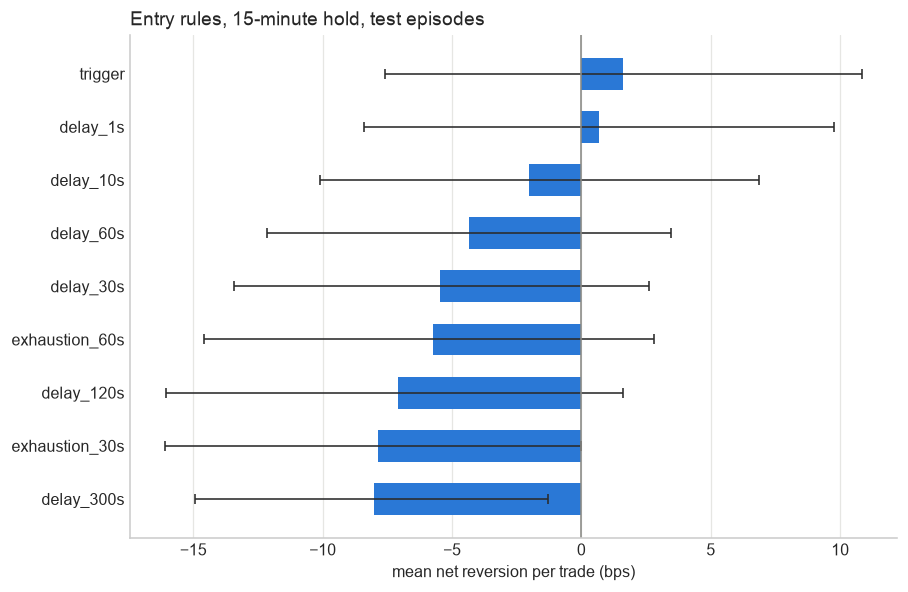

In [8]:
view = rule_table.filter(pl.col('holding_seconds') == HOLDING_SECONDS).sort('mean_net_bps')
fig, ax = plt.subplots(figsize=(8, 0.45 * view.height + 1.2))
positions = np.arange(view.height)
ax.barh(positions, view['mean_net_bps'], color=SERIES[0], height=0.6)
ax.errorbar(view['mean_net_bps'], positions,
            xerr=[view['mean_net_bps'] - view['net_ci_low'],
                  view['net_ci_high'] - view['mean_net_bps']],
            fmt='none', ecolor=INK, elinewidth=1, capsize=3)
ax.set_yticks(positions, view['rule'])
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlabel('mean net reversion per trade (bps)')
ax.set_title(f'Entry rules, {HOLDING_SECONDS // 60}-minute hold, {PERIOD} episodes',
             loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## 5. Which episodes revert?

Mean net edge for the selected rule and holding period, split by features known
at the trigger (and, separately marked, the ex-post open-interest label).
Tercile cut points come from calibration episodes only.

In [9]:
selected = trades.filter(
    (pl.col('rule') == RULE) & (pl.col('holding_seconds') == HOLDING_SECONDS)
)
calibration = episodes_all.filter(
    (pl.col('target_per_year') == TARGET_PER_YEAR) & (pl.col('period') == 'calibration')
)

def split_rows(feature, label):
    cuts = calibration[feature].drop_nans().drop_nulls().quantile(1 / 3), \
        calibration[feature].drop_nans().drop_nulls().quantile(2 / 3)
    output = []
    for name, condition in [
        ('low', pl.col(feature) < cuts[0]),
        ('middle', (pl.col(feature) >= cuts[0]) & (pl.col(feature) < cuts[1])),
        ('high', pl.col(feature) >= cuts[1]),
    ]:
        frame = selected.filter(condition)
        mean, low, high = day_bootstrap(frame['net_bps'], frame['day'])
        output.append({'feature': label, 'group': name, 'trades': frame.height,
                       'mean_net_bps': mean, 'ci_low': low, 'ci_high': high})
    return output

rows = []
for feature, label in [
    ('oi_change_1h_realtime_pct', 'OI change 1h (real time)'),
    ('aggression_share', 'aggression share'),
    ('spread_proxy_bps', 'spread proxy'),
    ('oi_change_episode_label_pct', 'OI change over episode (EX-POST)'),
]:
    rows.extend(split_rows(feature, label))
for name, condition in [
    ('scheduled release', pl.col('scheduled_release_window')),
    ('unscheduled', ~pl.col('scheduled_release_window')),
    ('down move', pl.col('direction') < 0),
    ('up move', pl.col('direction') > 0),
]:
    frame = selected.filter(condition)
    mean, low, high = day_bootstrap(frame['net_bps'], frame['day'])
    rows.append({'feature': 'category', 'group': name, 'trades': frame.height,
                 'mean_net_bps': mean, 'ci_low': low, 'ci_high': high})
pl.DataFrame(rows)

feature,group,trades,mean_net_bps,ci_low,ci_high
str,str,i64,f64,f64,f64
"""OI change 1h (real time)""","""low""",143,4.11,-14.21,24.37
"""OI change 1h (real time)""","""middle""",143,-0.56,-13.08,11.59
"""OI change 1h (real time)""","""high""",94,1.08,-13.76,15.01
"""aggression share""","""low""",111,11.41,-8.70,33.36
"""aggression share""","""middle""",103,-10.52,-28.63,7.34
"""aggression share""","""high""",166,2.56,-8.61,13.79
"""spread proxy""","""low""",232,-14.30,-23.32,-5.28
"""spread proxy""","""middle""",72,5.04,-19.91,29.26
"""spread proxy""","""high""",76,46.88,20.30,75.90


## 6. Stability by year

In [10]:
selected.group_by('year').agg(
    pl.len().alias('trades'),
    pl.col('gross_bps').mean().alias('mean_gross_bps'),
    pl.col('net_bps').mean().alias('mean_net_bps'),
    pl.col('net_bps').median().alias('median_net_bps'),
    (pl.col('net_bps') > 0).mean().alias('hit_rate'),
).sort('year')

year,trades,mean_gross_bps,mean_net_bps,median_net_bps,hit_rate
i32,u32,f64,f64,f64,f64
2023,177,4.10,-7.75,5.75,0.56
2024,89,46.06,33.45,19.86,0.65
2025,78,0.84,-10.51,-8.87,0.44
2026,36,6.13,-4.92,7.40,0.61


## Reading

See `alpha-search/reports/stress-episodes-v1-initial-results.md` for the
written interpretation.